# Matching - PySpark version

In [1]:
# matching.py

import os
import json
import numpy as np
import pandas as pd

from typing import List, Optional, Dict, Any

from pyspark.sql import DataFrame, Window
from pyspark.sql import functions as F

StatementMeta(, 5f071e4c-b401-42f0-bdf3-ccfa71882f9e, 3, Finished, Available, Finished, False)

In [7]:
%run ./matching_process

StatementMeta(, 5f071e4c-b401-42f0-bdf3-ccfa71882f9e, 12, Finished, Available, Finished, True)

In [8]:
%run ./prepare_matching_data

StatementMeta(, 5f071e4c-b401-42f0-bdf3-ccfa71882f9e, 13, Finished, Available, Finished, True)

In [4]:
%run ./matching_validation

StatementMeta(, 5f071e4c-b401-42f0-bdf3-ccfa71882f9e, 9, Finished, Available, Finished, True)

In [5]:
%run ./consumption_cohort

StatementMeta(, 5f071e4c-b401-42f0-bdf3-ccfa71882f9e, 10, Finished, Available, Finished, True)

## Load Data

In [6]:
month_result = pd.read_parquet("/lakehouse/default/Files/month_data")

month_result_high_all = month_result[
    month_result["price"].isin(["high", "all"])
]

print(month_result.shape)
print(month_result_high_all.shape)

month_result_spark = spark.createDataFrame(month_result_high_all)

StatementMeta(, 5f071e4c-b401-42f0-bdf3-ccfa71882f9e, 11, Finished, Available, Finished, False)

(4538578, 17)
(2684193, 17)


In [7]:
month_result_spark.show()

StatementMeta(, c048e1d9-647f-4b22-ba8b-dccd0978c065, 12, Finished, Available, Finished, False)

+------------------+-------------------+-----+-------------+-------------------+-----------------+-------------------+-----------------+-------------------+-----------------+---------------------+--------------------+----------------+------------+-----------+-----------------+-----------+
|               aID|           TIDPUNKT|price|tariff_active|         peak1_time|peak1_consumption|         peak2_time|peak2_consumption|         peak3_time|peak3_consumption|top3_mean_consumption|variance_consumption|mean_consumption|tariff_start|tariff_plan|total_consumption|usage_group|
+------------------+-------------------+-----+-------------+-------------------+-----------------+-------------------+-----------------+-------------------+-----------------+---------------------+--------------------+----------------+------------+-----------+-----------------+-----------+
|735999166200085868|2023-07-01 00:00:00|  all|            0|2023-07-31 18:00:00|       1.51100000|2023-07-25 18:00:00|       1.450

## Matching


StatementMeta(, de67c1a4-2fd7-4877-9a3d-c6b486c00f5e, 14, Finished, Available, Finished, False)

Preparing full risk set (for calendar matching)...
Preparing base data...
Building risk set...
risk_rows count = 11355189
Running calendar matching (k=5)...
Running calendar-aligned matching...
risk_rows count = 11355189
+----------+-------+-------+
|Ti        |group  |count  |
+----------+-------+-------+
|2025-03-01|control|1129558|
|2025-03-01|treated|14952  |
|2025-04-01|control|1130134|
|2025-04-01|treated|8010   |
|2025-05-01|control|1130709|
|2025-05-01|treated|3358   |
|2025-06-01|control|1131266|
|2025-06-01|treated|3000   |
|2025-07-01|control|1131805|
|2025-07-01|treated|1536   |
|2025-08-01|control|1131962|
|2025-08-01|treated|960    |
|2025-09-01|control|1132102|
|2025-09-01|treated|1176   |
|2025-10-01|control|1132228|
|2025-10-01|treated|1200   |
|2025-11-01|control|1132347|
|2025-11-01|treated|3529   |
|2025-12-01|control|1132453|
|2025-12-01|treated|2904   |
+----------+-------+-------+

Building calendar-aligned profiles ...
profiles count = 946088
Standardizing by co

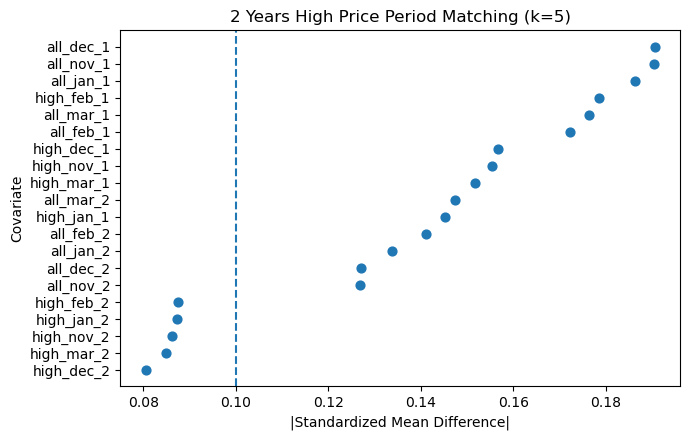

Rebuilding validation data...
  Matching vars window:     [t-24, t-0)
  Non-matching vars window: [t-24, t-0)
Validation rows (matching vars) count = 234141
Profiles rebuilt for matching vars
Validation rows (non-matching vars) count = 234141
Profiles rebuilt for non-matching vars

(No matching variables available)

------------------------------------------------------------


=== NON-MATCHING VARIABLES CHECK [24, 0) ===

--- OVERALL ---
+-------------------------+-------------------+-------------------+--------------------+
|covariate                |treated_mean       |control_mean       |SMD                 |
+-------------------------+-------------------+-------------------+--------------------+
|peak_mean_all            |6.135093434931673  |5.4922396103284825 |0.21826563498145693 |
|peak_sd_all              |1.639156555985535  |1.391092796185947  |0.266773194422657   |
|peak_volatility_all      |0.9227173670289011 |0.7581753627716189 |0.36652949240994726 |
|mean_consumption_all  

In [9]:

# ============================================================
# Step 1: FULL risk set（calendar 必須用完整月份）
# ============================================================

print("Preparing full risk set (for calendar matching)...")

risk_rows_full = prepare_matching_data(
    sdf=month_result_spark,
    lookback_months=24,      # cover 2 years
    match_months=None,       # ❗不能限制月份
    control_type="never_treated",
    verbose=True,
    price_values=["high", "all"],
)


# ============================================================
# Step 2: calendar matching (k = 5)
# ============================================================

print("Running calendar matching (k=5)...")

res_calendar2 = run_calendar_matching_aligned(
    risk_rows=risk_rows_full,   # ✅ 改這裡
    output_folder="Files/output/matching_all+high/calendar2",
    lookback_years=2,
    match_months=[1,2,3,11,12],
    k_neighbors=5,              
    verbose=True,
    save_output=False,
    control_type="never_treated"
)


# ============================================================
# Step 3: save
# ============================================================

save_matching_results_fabric(
    res=res_calendar2,
    folder="Files/output/matching_all+high/calendar2",
    config={
        "type": "calendar",
        "k_neighbors": 5,
        "match_months": [1,2,3,11,12]
    },
)


# ============================================================
# Step 4: love plot
# ============================================================

love_plot_from_spark(
    res_calendar2["balance"],
    output_path=None, 
    title="2 Years High Price Period Matching (k=5)"
)


# ============================================================
# Step 5: validation（🔥一定要有 sdf）
# ============================================================

check_balance_full_safe(
    res=res_calendar2,
    sdf=month_result_spark,

    match_start_month=24,
    match_end_month=0,

    extra_start_month=24,
    extra_end_month=0,

    calendar_start_month=24,
    calendar_end_month=0,

    price_values=["high", "all"],
)

StatementMeta(, 5f071e4c-b401-42f0-bdf3-ccfa71882f9e, 14, Finished, Available, Finished, False)

Preparing full risk set (for calendar matching)...
Preparing base data...
Building risk set...
risk_rows count = 5684081
Running calendar matching (k=5)...
Running calendar-aligned matching...
risk_rows count = 5684081
+----------+-------+------+
|Ti        |group  |count |
+----------+-------+------+
|2025-03-01|control|566104|
|2025-03-01|treated|7495  |
|2025-04-01|control|566173|
|2025-04-01|treated|4008  |
|2025-05-01|control|566246|
|2025-05-01|treated|1680  |
|2025-06-01|control|566314|
|2025-06-01|treated|1500  |
|2025-07-01|control|566371|
|2025-07-01|treated|768   |
|2025-08-01|control|566423|
|2025-08-01|treated|480   |
|2025-09-01|control|566472|
|2025-09-01|treated|588   |
|2025-10-01|control|566514|
|2025-10-01|treated|600   |
|2025-11-01|control|566547|
|2025-11-01|treated|1773  |
|2025-12-01|control|566573|
|2025-12-01|treated|1452  |
+----------+-------+------+

Building calendar-aligned profiles ...
profiles count = 946050
Standardizing by controls ...
profiles_z coun

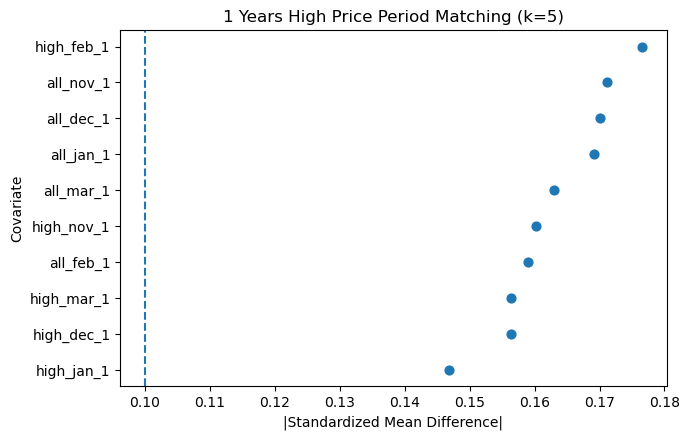

Rebuilding validation data...
  Matching vars window:     [t-24, t-12)
  Non-matching vars window: [t-12, t-0)
Validation rows (matching vars) count = 118281
Profiles rebuilt for matching vars
Validation rows (non-matching vars) count = 118799
Profiles rebuilt for non-matching vars

(No matching variables available)

------------------------------------------------------------


=== NON-MATCHING VARIABLES CHECK [12, 0) ===

--- OVERALL ---
+-------------------------+-------------------+-------------------+---------------------+
|covariate                |treated_mean       |control_mean       |SMD                  |
+-------------------------+-------------------+-------------------+---------------------+
|peak_mean_all            |6.3101629349978925 |5.631708220945275  |0.21916835644634836  |
|peak_sd_all              |1.4082899333983048 |1.2174903316032384 |0.20888696268582616  |
|peak_volatility_all      |0.9087083072405471 |0.755287689081418  |0.2883729704851644   |
|mean_consumptio

In [9]:
# 1 year
# ============================================================
# Step 1: FULL risk set（calendar 必須用完整月份）
# ============================================================

print("Preparing full risk set (for calendar matching)...")

risk_rows_full = prepare_matching_data(
    sdf=month_result_spark,
    lookback_months=12,      # cover 2 years
    match_months=None,       # ❗不能限制月份
    control_type="never_treated",
    verbose=True,
    price_values=["high", "all"],
)


# ============================================================
# Step 2: calendar matching (k = 5)
# ============================================================

print("Running calendar matching (k=5)...")

res_calendar2 = run_calendar_matching_aligned(
    risk_rows=risk_rows_full,   # ✅ 改這裡
    output_folder="Files/output/matching_all+high/calendar2_1year",
    lookback_years=1,
    match_months=[1,2,3,11,12],
    k_neighbors=5,              
    verbose=True,
    save_output=False,
    control_type="never_treated"
)


# ============================================================
# Step 3: save
# ============================================================

save_matching_results_fabric(
    res=res_calendar2,
    folder="Files/output/matching_all+high/calendar2_1year",
    config={
        "type": "calendar",
        "k_neighbors": 5,
        "match_months": [1,2,3,11,12]
    },
)


# ============================================================
# Step 4: love plot
# ============================================================

love_plot_from_spark(
    res_calendar2["balance"],
    output_path=None, 
    title="1 Years High Price Period Matching (k=5)"
)


# ============================================================
# Step 5: validation（🔥一定要有 sdf）
# ============================================================

check_balance_full_safe(
    res=res_calendar2,
    sdf=month_result_spark,

    match_start_month=24,
    match_end_month=12,

    extra_start_month=12,
    extra_end_month=0,

    calendar_start_month=24,
    calendar_end_month=0,

    price_values=["high", "all"],
)

StatementMeta(, 059aa6c6-6dba-48e0-8008-0f5c8db231d0, 17, Finished, Available, Finished, False)

Running summary matching 4...
Preparing base data...
Building risk set...
risk_rows count = 5684081
risk_rows count = 5684081
+----------+-------+------+
|Ti        |group  |count |
+----------+-------+------+
|2025-03-01|control|566104|
|2025-03-01|treated|7495  |
|2025-04-01|control|566173|
|2025-04-01|treated|4008  |
|2025-05-01|control|566246|
|2025-05-01|treated|1680  |
|2025-06-01|control|566314|
|2025-06-01|treated|1500  |
|2025-07-01|control|566371|
|2025-07-01|treated|768   |
|2025-08-01|control|566423|
|2025-08-01|treated|480   |
|2025-09-01|control|566472|
|2025-09-01|treated|588   |
|2025-10-01|control|566514|
|2025-10-01|treated|600   |
|2025-11-01|control|566547|
|2025-11-01|treated|1773  |
|2025-12-01|control|566573|
|2025-12-01|treated|1452  |
+----------+-------+------+

Building summary profiles ...
profiles count = 473947
Standardizing by controls ...
profiles_z count = 473947
Matching top-k ...
matches count = 8480
Building matched profiles ...
matched_profiles coun

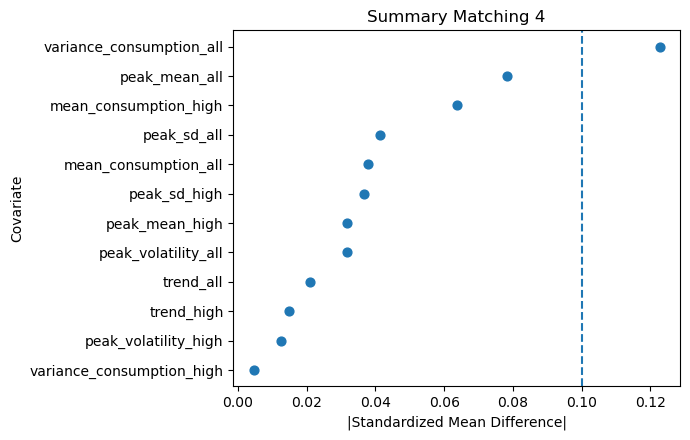

Rebuilding validation data...
  Matching vars window:     [t-24, t-12)
  Non-matching vars window: [t-12, t-0)
Validation rows (matching vars) count = 114905
Profiles rebuilt for matching vars
Validation rows (non-matching vars) count = 115301
Profiles rebuilt for non-matching vars

=== MATCHING VARIABLES CHECK [24, 12) ===

--- OVERALL ---
+-------------------------+-------------------+-------------------+---------------------+
|covariate                |treated_mean       |control_mean       |SMD                  |
+-------------------------+-------------------+-------------------+---------------------+
|peak_mean_high           |5.335059390903718  |5.341018989053342  |-0.002303661620517135|
|peak_sd_high             |0.9902249765413147 |0.9848200535822996 |0.007100576856477614 |
|peak_volatility_high     |1.0452439548631616 |1.0604684891405192 |-0.01788759140614847 |
|mean_consumption_high    |1.862230487574452  |1.8827265705287664 |-0.019601466791904724|
|variance_consumption_high|

In [11]:
print("Running summary matching 4...")

# ============================================================
# STEP 0: build risk_rows（🔥必要）
# ============================================================
risk_rows = prepare_matching_data(
    sdf=month_result_spark,
    lookback_months=12,
    control_type="never_treated",
    verbose=True,
    price_values=["high", "all"],
)

# ============================================================
# STEP 1: matching（🔥改成用 risk_rows）
# ============================================================
res_summary_4 = run_summary_matching_pipeline(
    output_folder="Files/output/matching_all+high/summary_4",
    risk_rows=risk_rows,  
    lookback_months=12,
    summary_vars=[
        "peak_mean_high",
        "peak_sd_high",
        "peak_volatility_high",
        "mean_consumption_high",
        "variance_consumption_high",
        "trend_high",

        "peak_mean_all",
        "peak_sd_all",
        "peak_volatility_all",
        "mean_consumption_all",
        "variance_consumption_all",
        "trend_all"
    ],
    verbose=True,
    save_output=False,
    control_type="never_treated"
)

# ============================================================
# STEP 2: save（OK）
# ============================================================
save_matching_results_fabric(
    res=res_summary_4,
    folder="Files/output/matching_all+high/summary_4",
    config={
        "type": "summary",
        "vars": [
            "peak_mean",
            "peak_sd",
            "peak_volatility",
            "mean_consumption",
            "variance_consumption",
            "trend"
        ]
    },
)

# ============================================================
# STEP 3: love plot（OK）
# ============================================================
love_plot_from_spark(
    res_summary_4["balance"],
    output_path=None,
    title="Summary Matching 4"
)

# ============================================================
# STEP 4: validation（🔥一定要加 sdf）
# ============================================================
check_balance_full_safe(
    res=res_summary_4,
    sdf=month_result_spark,

    match_start_month=24,
    match_end_month=12,

    extra_start_month=12,
    extra_end_month=0,

    calendar_start_month=24,
    calendar_end_month=0,

    price_values=["high", "all"],
)

StatementMeta(, 5f071e4c-b401-42f0-bdf3-ccfa71882f9e, 15, Finished, Available, Finished, False)

Preparing full risk set (for calendar matching)...
Preparing base data...
Building risk set...
risk_rows count = 5684081
Running calendar matching (k=3)...
Running calendar-aligned matching...
risk_rows count = 5684081
+----------+-------+------+
|Ti        |group  |count |
+----------+-------+------+
|2025-03-01|control|566104|
|2025-03-01|treated|7495  |
|2025-04-01|control|566173|
|2025-04-01|treated|4008  |
|2025-05-01|control|566246|
|2025-05-01|treated|1680  |
|2025-06-01|control|566314|
|2025-06-01|treated|1500  |
|2025-07-01|control|566371|
|2025-07-01|treated|768   |
|2025-08-01|control|566423|
|2025-08-01|treated|480   |
|2025-09-01|control|566472|
|2025-09-01|treated|588   |
|2025-10-01|control|566514|
|2025-10-01|treated|600   |
|2025-11-01|control|566547|
|2025-11-01|treated|1773  |
|2025-12-01|control|566573|
|2025-12-01|treated|1452  |
+----------+-------+------+

Building calendar-aligned profiles ...
profiles count = 946050
Standardizing by controls ...
profiles_z coun

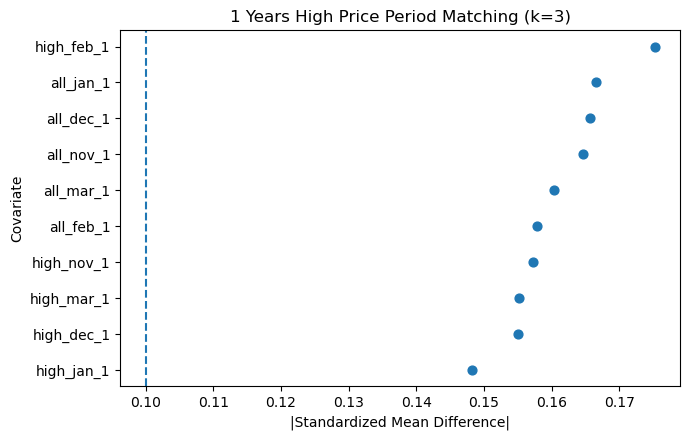

Rebuilding validation data...
  Matching vars window:     [t-24, t-12)
  Non-matching vars window: [t-12, t-0)
Validation rows (matching vars) count = 79464
Profiles rebuilt for matching vars
Validation rows (non-matching vars) count = 79897
Profiles rebuilt for non-matching vars

(No matching variables available)

------------------------------------------------------------


=== NON-MATCHING VARIABLES CHECK [12, 0) ===

--- OVERALL ---
+-------------------------+-------------------+-------------------+---------------------+
|covariate                |treated_mean       |control_mean       |SMD                  |
+-------------------------+-------------------+-------------------+---------------------+
|peak_mean_all            |6.310162934997892  |5.643465388245557  |0.21542575356104837  |
|peak_sd_all              |1.4082899333983057 |1.2238304925200976 |0.2014278137228734   |
|peak_volatility_all      |0.9087083072405472 |0.7568529649247432 |0.2852012431296178   |
|mean_consumption_

In [10]:
# 1 year
# ============================================================
# Step 1: FULL risk set（calendar 必須用完整月份）
# ============================================================

print("Preparing full risk set (for calendar matching)...")

risk_rows_full = prepare_matching_data(
    sdf=month_result_spark,
    lookback_months=12,      # cover 2 years
    match_months=None,       # ❗不能限制月份
    control_type="never_treated",
    verbose=True,
    price_values=["high", "all"],
)


# ============================================================
# Step 2: calendar matching (k = 3)
# ============================================================

print("Running calendar matching (k=3)...")

res_calendar2 = run_calendar_matching_aligned(
    risk_rows=risk_rows_full,   # ✅ 改這裡
    output_folder="Files/output/matching_all+high/calendar2_1year_k=3",
    lookback_years=1,
    match_months=[1,2,3,11,12],
    k_neighbors=3,              
    verbose=True,
    save_output=False,
    control_type="never_treated"
)


# ============================================================
# Step 3: save
# ============================================================

save_matching_results_fabric(
    res=res_calendar2,
    folder="Files/output/matching_all+high/calendar2_1year_k=3",
    config={
        "type": "calendar",
        "k_neighbors": 3,
        "match_months": [1,2,3,11,12]
    },
)


# ============================================================
# Step 4: love plot
# ============================================================

love_plot_from_spark(
    res_calendar2["balance"],
    output_path=None, 
    title="1 Years High Price Period Matching (k=3)"
)


# ============================================================
# Step 5: validation（🔥一定要有 sdf）
# ============================================================

check_balance_full_safe(
    res=res_calendar2,
    sdf=month_result_spark,

    match_start_month=24,
    match_end_month=12,

    extra_start_month=12,
    extra_end_month=0,

    calendar_start_month=24,
    calendar_end_month=0,

    price_values=["high", "all"],
)